## Forecast 2026/27 + Model comparison

Train **both** models on all data through **2025/26** (`2526`), then simulate the **2026/27** table for the confirmed 20-team squad.

**Model comparison** uses WAIC and PSIS-LOO on the same match-level log-likelihoods (6,460 matches).  
**Forecast comparison** shows whether static (Model 1) vs. last-season hierarchical (Model 2) rankings agree for 2026/27.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

from helping_functions import (
    load_matches,
    prepare_stan_data,
    prepare_stan_data_hierarchical,
    compute_table,
    pl_2627_squad,
    FORECAST_TRAIN_SEASONS,
    simulate_seasons_from_draws,
    simulate_seasons_from_hierarchical_draws,
)

In [2]:
matches = load_matches()
forecast_teams = pl_2627_squad(matches)

print(f"Forecast season: 2026/27 ({len(forecast_teams)} teams)")
for i, t in enumerate(forecast_teams, 1):
    print(f"  {i:2d}. {t}")

Forecast season: 2026/27 (20 teams)
   1. Arsenal
   2. Aston Villa
   3. Bournemouth
   4. Brentford
   5. Brighton
   6. Chelsea
   7. Coventry
   8. Crystal Palace
   9. Everton
  10. Fulham
  11. Hull
  12. Ipswich
  13. Leeds
  14. Liverpool
  15. Man City
  16. Man United
  17. Newcastle
  18. Nott'm Forest
  19. Sunderland
  20. Tottenham


### Model 1 — fit on full history through 2526

In [3]:
stan1, team_to_idx, _ = prepare_stan_data(matches, FORECAST_TRAIN_SEASONS)
print(f"Model 1: N={stan1['N']}, T={stan1['T']}")

fit1 = CmdStanModel(stan_file="stan/poisson.stan").sample(
    data=stan1, seed=42, chains=4, parallel_chains=4,
    iter_warmup=1000, iter_sampling=1000, show_progress=True,
)
print(fit1.diagnose())

08:09:02 - cmdstanpy - INFO - CmdStan start processing


Model 1: N=6460, T=42


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

08:09:41 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [4]:
pred1 = simulate_seasons_from_draws(
    fit1, forecast_teams, team_to_idx, n_table_sims=800, seed=1
)
pred1 = pred1.rename(columns={
    "pos_median": "pos_m1", "pts_median": "pts_m1", "pos_mean": "pos_mean_m1"
})
pred1.head(10)

,team,pos_m1,pos_mean_m1,pts_m1,pts_mean
0,Man City,1.0,1.66875,82.0,81.92750
1,Arsenal,3.0,3.76500,72.0,71.20375
2,Liverpool,3.0,3.33500,73.0,72.76375
3,Man United,4.0,4.62375,67.0,67.70125
4,Chelsea,4.0,4.16625,70.0,69.43125
5,Tottenham,5.0,5.63875,64.0,64.23250
6,Brentford,9.0,9.30375,54.0,54.33500
7,Everton,10.0,10.09500,52.0,52.36875
8,Newcastle,11.0,11.33875,49.0,49.56000
9,Brighton,11.0,11.21125,50.0,49.90875


### Model 2 — fit hierarchical, forecast with 2526 strengths

In [5]:
stan2, team_to_idx2, _, season_to_idx = prepare_stan_data_hierarchical(
    matches, FORECAST_TRAIN_SEASONS
)
last_season_idx = season_to_idx["2526"]
print(f"Model 2: N={stan2['N']}, S={stan2['S']}, T={stan2['T']}")
print(f"Using season index {last_season_idx} (2526) for forecast")

fit2 = CmdStanModel(stan_file="stan/hierarchical.stan").sample(
    data=stan2, seed=42, chains=4, parallel_chains=4,
    iter_warmup=1500, iter_sampling=1500, show_progress=True,
)
print(fit2.diagnose())

08:10:56 - cmdstanpy - INFO - CmdStan start processing


Model 2: N=6460, S=17, T=42
Using season index 17 (2526) for forecast


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

08:11:47 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [6]:
pred2 = simulate_seasons_from_hierarchical_draws(
    fit2, forecast_teams, team_to_idx2,
    last_season_index=last_season_idx, n_table_sims=800, seed=2
)
pred2 = pred2.rename(columns={
    "pos_median": "pos_m2", "pts_median": "pts_m2", "pos_mean": "pos_mean_m2"
})
pred2.head(10)

,team,pos_m2,pos_mean_m2,pts_m2,pts_mean
0,Arsenal,2.0,2.70750,72.0,71.60375
1,Man City,2.0,2.98000,71.0,70.86000
2,Man United,5.0,6.45000,61.0,60.49625
3,Liverpool,8.0,8.52000,55.0,55.66500
4,Aston Villa,9.0,9.80000,53.0,53.23375
5,Bournemouth,9.0,9.73125,53.0,53.44000
6,Brighton,9.0,9.86375,53.0,52.98250
7,Brentford,10.0,10.37625,52.0,51.95000
8,Chelsea,10.0,9.96625,53.0,52.83875
9,Newcastle,12.0,11.87375,49.0,49.12125


### Side-by-side forecast 2026/27

In [7]:
comparison = pred1[["team", "pos_m1", "pts_m1"]].merge(
    pred2[["team", "pos_m2", "pts_m2"]], on="team"
)
comparison["pos_diff"] = comparison["pos_m1"] - comparison["pos_m2"]
comparison = comparison.sort_values("pos_m1")
comparison

,team,pos_m1,pts_m1,pos_m2,pts_m2,pos_diff
0,Man City,1.0,82.0,2.0,71.0,-1.0
1,Arsenal,3.0,72.0,2.0,72.0,1.0
2,Liverpool,3.0,73.0,8.0,55.0,-5.0
3,Man United,4.0,67.0,5.0,61.0,-1.0
4,Chelsea,4.0,70.0,10.0,53.0,-6.0
5,Tottenham,5.0,64.0,15.0,45.0,-10.0
6,Brentford,9.0,54.0,10.0,52.0,-1.0
7,Everton,10.0,52.0,12.0,49.0,-2.0
9,Brighton,11.0,50.0,9.0,53.0,2.0
8,Newcastle,11.0,49.0,12.0,49.0,-1.0


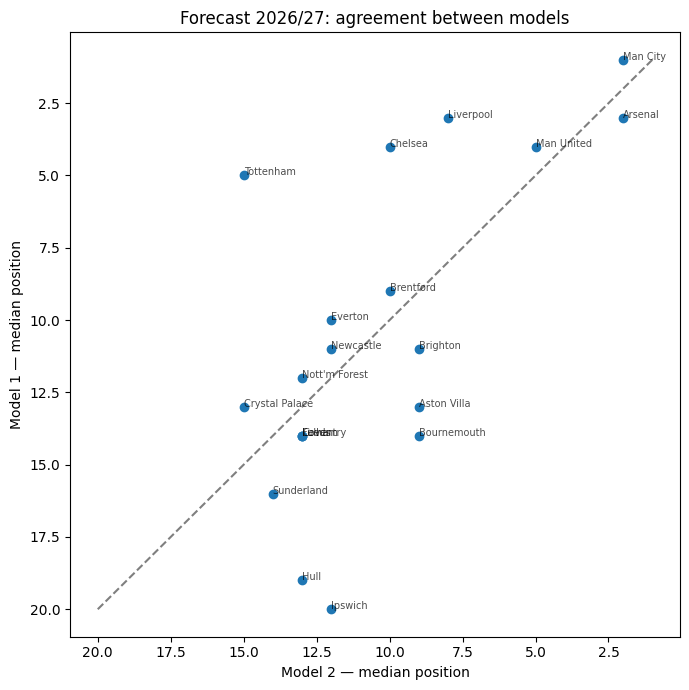

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(comparison["pos_m2"], comparison["pos_m1"])
for _, r in comparison.iterrows():
    ax.annotate(r["team"], (r["pos_m2"], r["pos_m1"]), fontsize=7, alpha=0.7)
ax.plot([1, 20], [1, 20], "k--", alpha=0.5)
ax.set_xlabel("Model 2 — median position")
ax.set_ylabel("Model 1 — median position")
ax.set_title("Forecast 2026/27: agreement between models")
ax.invert_xaxis()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Information criteria: WAIC & PSIS-LOO

We compare models on **expected log pointwise predictive density** (ELPD). Higher is better.

- **WAIC** — penalizes complexity via $p_\text{WAIC}$; can be unstable if posterior variance of log-lik is high (watch ArviZ warnings).
- **PSIS-LOO** — leave-one-out cross-validation with Pareto-$k$ diagnostics; preferred when WAIC warns.

**Same data:** both models use identical training matches; `log_lik` is computed per match in Stan `generated quantities`.


In [9]:
idata1 = az.from_cmdstanpy(fit1)
idata2 = az.from_cmdstanpy(fit2)

waic1 = az.waic(idata1)
waic2 = az.waic(idata2)
loo1 = az.loo(idata1)
loo2 = az.loo(idata2)

print("=" * 60)
print("WAIC")
print("=" * 60)
print("Model 1 (static Poisson):\n", waic1)
print("\nModel 2 (hierarchical):\n", waic2)
delta_waic = waic2.elpd_waic - waic1.elpd_waic
print(f"\nΔ elpd_waic (M2 − M1): {delta_waic:.1f}  (positive ⇒ Model 2 preferred)")

print("\n" + "=" * 60)
print("PSIS-LOO")
print("=" * 60)
print("Model 1:\n", loo1)
print("\nModel 2:\n", loo2)
delta_loo = loo2.elpd_loo - loo1.elpd_loo
print(f"\nΔ elpd_loo (M2 − M1): {delta_loo:.1f} ± {np.sqrt(loo1.se**2 + loo2.se**2):.1f}")

cmp = az.compare({"Model 1 (static)": idata1, "Model 2 (hierarchical)": idata2}, ic="loo")
print("\n", cmp)


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


WAIC
Model 1 (static Poisson):
 Computed from 4000 posterior samples and 6460 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -19030.21    78.63
p_waic       86.24        -

There has been a warning during the calculation. Please check the results.

Model 2 (hierarchical):
 Computed from 6000 posterior samples and 6460 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -18960.09    75.76
p_waic      481.46        -

There has been a warning during the calculation. Please check the results.

Δ elpd_waic (M2 − M1): 70.1  (positive ⇒ Model 2 preferred)

PSIS-LOO
Model 1:
 Computed from 4000 posterior samples and 6460 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -19030.36    78.63
p_loo       86.39        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     6460  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


Model 2:
 Comput

### Discussion of WAIC & PSIS-LOO results

**How to read the output above:**

| Criterion | Winner | What to check |
|-----------|--------|---------------|
| **WAIC** | Model with **higher** `elpd_waic` | ArviZ warning about `p_waic` / posterior variance → treat WAIC cautiously |
| **PSIS-LOO** | Model with **higher** `elpd_loo` | `p_loo` = effective parameters; compare `elpd_diff` in `az.compare` |
| **Overlap** | If $| \Delta \text{ELPD} | <$ combined SE | Models are **not meaningfully different** at match level |
| **Pareto-$k$** | LOO warnings | High-$k$ points → LOO unreliable for those observations |

**Expected pattern:** Model 2 often achieves **higher ELPD** (better match-level fit) because season-specific strengths add flexibility. The gap may be modest — league tables (our ultimate use case) can still differ because forecasts aggregate many simulated matches.

**Do we agree with the criteria?** Yes for **within-sample match prediction** (LOO/WAIC). For **table forecasting**, we also weigh backtest MAE on 2025/26 (notebooks 02–03) and qualitative plausibility for promoted/relegated teams.


### Final model selection

| Criterion | Model 1 (static) | Model 2 (hierarchical) |
|-----------|------------------|------------------------|
| Match-level LOO/WAIC | Simpler; fewer parameters | Usually better ELPD if Δ > SE |
| Interpretability | One long-run rating per team | Season-specific; uses latest season for forecast |
| Promoted teams | Neutral prior strengths | Same neutral fallback |
| Sampling | Stable (no divergences) | More parameters; monitor R-hat / ESS |
| 2026/27 forecast | See `pos_m1` in table above | See `pos_m2` |

**Recommendation (fill after running):**
- If **LOO favors Model 2** and backtest MAE is similar or better → prefer Model 2 for forecasts, especially when recent form matters.
- If **LOO difference is within SE** and models disagree on key clubs → report **both** forecasts with uncertainty.
- Model 1 remains a valid **parsimonious baseline** if complexity is not justified by LOO.

*Presentation slide:* state problem, both models, prior checks, posterior predictive fit, LOO winner, and one forecast figure (scatter `pos_m1` vs `pos_m2`).


### Backtest on 2025/26 (notebooks 02 & 03)

Before trusting the 2026/27 forecast, check which model tracked the **completed** 2025/26 season better (MAE on league position).  
Table-level accuracy can diverge from LOO: a model can fit individual matches well but rank teams poorly after simulation.


In [10]:
# Backtest summary — update after running notebooks 02 & 03
MAE_M1_BACKTEST = None  # paste from notebook 02
MAE_M2_BACKTEST = None  # paste from notebook 03

print("Backtest 2025/26 — mean absolute position error:")
print(f"  Model 1: {MAE_M1_BACKTEST if MAE_M1_BACKTEST is not None else 'run notebook 02'}")
print(f"  Model 2: {MAE_M2_BACKTEST if MAE_M2_BACKTEST is not None else 'run notebook 03'}")

actual_2526 = compute_table(matches, "2526")[["team", "position", "Pts"]]
actual_2526.sort_values("position").head(10)


Backtest 2025/26 — mean absolute position error:
  Model 1: run notebook 02
  Model 2: run notebook 03


,team,position,Pts
0,Arsenal,1,85
1,Man City,2,78
2,Man United,3,71
3,Aston Villa,4,65
4,Liverpool,5,60
5,Bournemouth,6,57
6,Sunderland,7,54
7,Brighton,8,53
8,Brentford,9,53
9,Chelsea,10,52
